# Firewall Log Classification - ML Project

This notebook classifies firewall log actions (`allow`, `drop`, `deny`, `reset-both`) using machine learning models: **Random Forest**, **Logistic Regression**, and **kNN**.

### Pipeline:
1. Data Loading & EDA
2. Data Cleaning (nulls, duplicates, outliers)
3. Feature Analysis (correlation)
4. Label Encoding
5. Train/Test Split
6. SMOTE (on training data only)
7. Feature Scaling (fit on train, transform test)
8. Model Training & Evaluation
9. Hyperparameter Tuning

## 1. Install Dependencies & Imports

In [3]:
!pip install scikit-plot

In [6]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy # Import scipy explicitly to allow setting its attribute

# Fix for scikit-plot's ImportError with newer scipy versions
try:
    from scipy import interp
except ImportError:
    # If scipy.interp is not available (e.g., in newer scipy versions),
    # try importing from numpy and assign it to scipy.interp
    import numpy
    if not hasattr(scipy, 'interp'):
        scipy.interp = numpy.interp

import scikitplot as sk


# so that plots show directly in the notebook
%matplotlib inline

# set seaborn style for plots
sns.set(style="darkgrid")
plt.rcParams['figure.figsize'] = (15, 5)
plt.style.use('ggplot')

seed = 42  # fix random seed so results are reproducible

import warnings  # to control warning messages

# ignore future warnings from sklearn to reduce clutter
warnings.filterwarnings(action="ignore", category=FutureWarning, module="sklearn")

## 2. Load Data & Initial EDA

In [7]:
import pandas as pd
DATA_PATH = 'log2.csv'
df = pd.read_csv(DATA_PATH, header=0)
df.head(5)


,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Action,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
0,57222,53,54587,53,allow,177,94,83,2,30,1,1
1,56258,3389,56258,3389,allow,4768,1600,3168,19,17,10,9
2,6881,50321,43265,50321,allow,238,118,120,2,1199,1,1
3,50553,3389,50553,3389,allow,3327,1438,1889,15,17,8,7
4,50002,443,45848,443,allow,25358,6778,18580,31,16,13,18


In [8]:
df.shape  # shows the number of rows and columns in the DataFrame

(65532, 12)

In [9]:
df.columns  # lists all the column names in the DataFrame

Index(['Source Port', 'Destination Port', 'NAT Source Port',
       'NAT Destination Port', 'Action', 'Bytes', 'Bytes Sent',
       'Bytes Received', 'Packets', 'Elapsed Time (sec)', 'pkts_sent',
       'pkts_received'],
      dtype='object')

In [10]:
df.info()  # shows a summary of the DataFrame, including number of rows, columns, data types, and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65532 entries, 0 to 65531
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Source Port           65532 non-null  int64 
 1   Destination Port      65532 non-null  int64 
 2   NAT Source Port       65532 non-null  int64 
 3   NAT Destination Port  65532 non-null  int64 
 4   Action                65532 non-null  object
 5   Bytes                 65532 non-null  int64 
 6   Bytes Sent            65532 non-null  int64 
 7   Bytes Received        65532 non-null  int64 
 8   Packets               65532 non-null  int64 
 9   Elapsed Time (sec)    65532 non-null  int64 
 10  pkts_sent             65532 non-null  int64 
 11  pkts_received         65532 non-null  int64 
dtypes: int64(11), object(1)
memory usage: 6.0+ MB


In [11]:
df.describe().T  # gives statistical summary of numerical columns and transposes it for easier reading

,count,mean,std,min,25%,50%,75%,max
Source Port,65532.0,49391.969343,1.525571e+04,0.0,49183.0,53776.5,58638.00,6.553400e+04
Destination Port,65532.0,10577.385812,1.846603e+04,0.0,80.0,445.0,15000.00,6.553500e+04
NAT Source Port,65532.0,19282.972761,2.197069e+04,0.0,0.0,8820.5,38366.25,6.553500e+04
NAT Destination Port,65532.0,2671.049930,9.739162e+03,0.0,0.0,53.0,443.00,6.553500e+04
Bytes,65532.0,97123.950085,5.618439e+06,60.0,66.0,168.0,752.25,1.269359e+09
Bytes Sent,65532.0,22385.796908,3.828139e+06,60.0,66.0,90.0,210.00,9.484772e+08
Bytes Received,65532.0,74738.153177,2.463208e+06,0.0,0.0,79.0,449.00,3.208818e+08
Packets,65532.0,102.866035,5.133002e+03,1.0,1.0,2.0,6.00,1.036116e+06
Elapsed Time (sec),65532.0,65.833577,3.024618e+02,0.0,0.0,15.0,30.00,1.082400e+04
pkts_sent,65532.0,41.399530,3.218871e+03,1.0,1.0,1.0,3.00,7.475200e+05


In [12]:
# Loop through all text (categorical) columns
for col in df.select_dtypes(include='object'):
    print(col)
    print(df[col].unique())

Action
['allow' 'drop' 'deny' 'reset-both']


### Check for Nulls & Duplicates


In [13]:
# Check for null values and duplicate rows

print("=== Null Values ===")
print(df.isnull().sum())  # shows number of nulls in each column
print(f"\nTotal nulls: {df.isnull().sum().sum()}")  # total number of nulls in the whole DataFrame

print("\n=== Duplicate Rows ===")
dup_count = df.duplicated().sum()  # count how many duplicate rows exist
print(f"Duplicate rows: {dup_count}")

if dup_count > 0:
    print(f"Removing {dup_count} duplicates")  # message showing duplicates will be removed
    df = df.drop_duplicates()  # remove duplicate rows
    print(f"Shape after removing duplicates: {df.shape}")  # show new shape after removal


=== Null Values ===
Source Port             0
Destination Port        0
NAT Source Port         0
NAT Destination Port    0
Action                  0
Bytes                   0
Bytes Sent              0
Bytes Received          0
Packets                 0
Elapsed Time (sec)      0
pkts_sent               0
pkts_received           0
dtype: int64

Total nulls: 0

=== Duplicate Rows ===
Duplicate rows: 8362
Removing 8362 duplicates
Shape after removing duplicates: (57170, 12)


In [14]:
# Make all column names lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Show the first 7 rows of the dataset
df.head(7)


,source_port,destination_port,nat_source_port,nat_destination_port,action,bytes,bytes_sent,bytes_received,packets,elapsed_time_(sec),pkts_sent,pkts_received
0,57222,53,54587,53,allow,177,94,83,2,30,1,1
1,56258,3389,56258,3389,allow,4768,1600,3168,19,17,10,9
2,6881,50321,43265,50321,allow,238,118,120,2,1199,1,1
3,50553,3389,50553,3389,allow,3327,1438,1889,15,17,8,7
4,50002,443,45848,443,allow,25358,6778,18580,31,16,13,18
5,51465,443,39975,443,allow,3961,1595,2366,21,16,12,9
6,60513,47094,45469,47094,allow,320,140,180,6,7,3,3


###  Feature Correlation Analysis


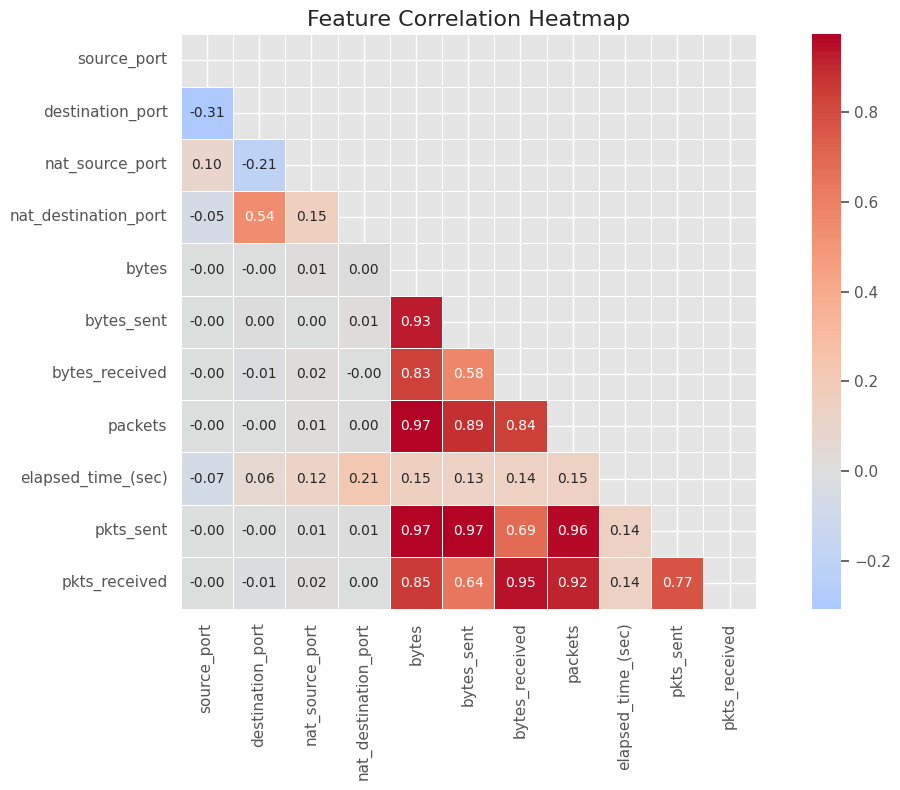


Highly correlated pairs (|r| > 0.9):
  bytes <-> bytes_sent: 0.933
  bytes <-> packets: 0.974
  bytes <-> pkts_sent: 0.967
  bytes_sent <-> pkts_sent: 0.974
  bytes_received <-> pkts_received: 0.946
  packets <-> pkts_sent: 0.961
  packets <-> pkts_received: 0.917


In [15]:
# Plot a heatmap to visualize correlations between numeric features
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()
# print highly correlated pairs (absolute correlation > 0.9)
print("\nHighly correlated pairs (|r| > 0.9):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            print(f"  {corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")

In [16]:
from collections import Counter

# Count how many times each value appears in the 'action' column
Counter(df.action)


Counter({'allow': 37439, 'drop': 11635, 'deny': 8042, 'reset-both': 54})

## 3. Data Preprocessing

### Label Encoding & Outlier Removal

In [17]:
from sklearn import preprocessing
from imblearn.over_sampling import SMOTE

# Encode the target feature
lab = preprocessing.LabelEncoder()
df['action'] = lab.fit_transform(df['action'])

# Create a new dataframe without the target feature
data_out = df.drop("action", axis=1)


# Select the features without the target column
features_only = df.drop("action", axis=1)

# Calculate the first (25%) and third (75%) quartiles for each feature
q1 = features_only.quantile(0.25)
q3 = features_only.quantile(0.75)

# Compute the interquartile range (IQR)
iqr = q3 - q1

# Define lower and upper bounds for outliers
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

# Filter out rows with any outlier in the features
clean_data = df[~((features_only < lower_limit) | (features_only > upper_limit)).any(axis=1)]

# Show how many rows were removed
print("Original rows:", df.shape[0])
print("Rows after removing outliers:", clean_data.shape[0])


Original rows: 57170
Rows after removing outliers: 29599


In [18]:
import pandas as pd
DATA_PATH = '/content/log2.csv'
df = pd.read_csv(DATA_PATH, header=0)
df.head(5)

,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Action,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
0,57222,53,54587,53,allow,177,94,83,2,30,1,1
1,56258,3389,56258,3389,allow,4768,1600,3168,19,17,10,9
2,6881,50321,43265,50321,allow,238,118,120,2,1199,1,1
3,50553,3389,50553,3389,allow,3327,1438,1889,15,17,8,7
4,50002,443,45848,443,allow,25358,6778,18580,31,16,13,18


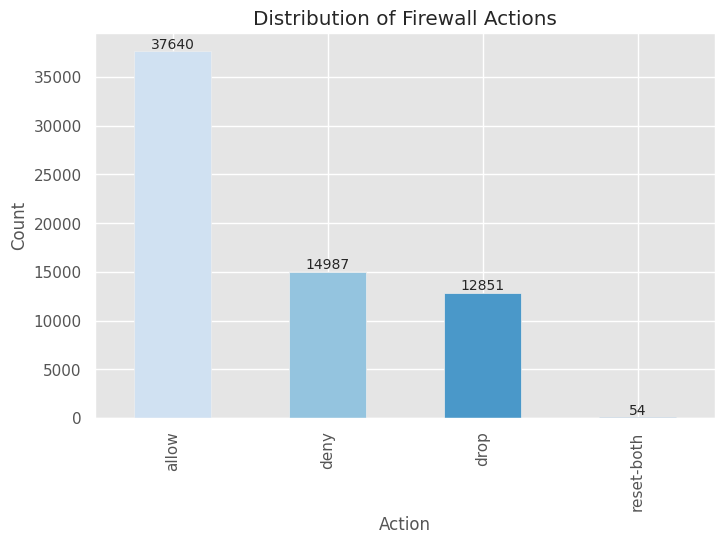

In [19]:
import seaborn as sns

counts = df['Action'].value_counts()

plt.figure(figsize=(8,5))
counts.plot(kind='bar', color=sns.color_palette("Blues", len(counts)))

for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.title("Distribution of Firewall Actions")
plt.xlabel("Action")
plt.ylabel("Count")
plt.show()

In [20]:
from collections import Counter

# Separate features and target from the cleaned dataset
feature = clean_data.drop("action", axis=1).values  # drop target column to get features
target = clean_data["action"].values  # extract target column

# check shapes and class distribution
print(f"Features shape: {feature.shape}")  # shape of feature matrix
print(f"Target distribution before SMOTE: {dict(Counter(target))}")  # show how many samples per class

Features shape: (29599, 11)
Target distribution before SMOTE: {np.int64(0): 17636, np.int64(2): 11635, np.int64(1): 328}


In [21]:
Counter(target)

Counter({np.int64(0): 17636, np.int64(2): 11635, np.int64(1): 328})

### Using SMOTE to prepare the data for modeling

In [22]:
from sklearn import model_selection
from imblearn.over_sampling import SMOTE
from collections import Counter

# Step 2: Split data into training and testing sets first
xtrain, xtest, ytrain, ytest = model_selection.train_test_split(
    feature, target, test_size=0.3, stratify=target, random_state=seed
)

print(f"Before SMOTE Train: {xtrain.shape}, Test: {xtest.shape}")  # check shapes
print(f"Train target distribution: {dict(Counter(ytrain))}")  # check class distribution in training set

# Step 3: Apply SMOTE only on training data to balance classes
sm = SMOTE(random_state=seed)
xtrain, ytrain = sm.fit_resample(xtrain, ytrain)  # generate synthetic samples for minority classes

print(f"\nAfter SMOTE Train: {xtrain.shape}")  # new training shape
print(f"Train target distribution after SMOTE: {dict(Counter(ytrain))}")  # check new class distribution
print(f"Test set unchanged: {xtest.shape}")  # test set remains the same


Before SMOTE Train: (20719, 11), Test: (8880, 11)
Train target distribution: {np.int64(0): 12345, np.int64(2): 8144, np.int64(1): 230}

After SMOTE Train: (37035, 11)
Train target distribution after SMOTE: {np.int64(0): 12345, np.int64(2): 12345, np.int64(1): 12345}
Test set unchanged: (8880, 11)


In [23]:
xtrain.shape, xtest.shape, ytrain.shape, ytest.shape  # check the shapes of training and testing sets for features and target


((37035, 11), (8880, 11), (37035,), (8880,))

In [24]:
from sklearn import preprocessing

# Standardize features by removing the mean and scaling to unit variance
scaler = preprocessing.StandardScaler()
xtrain = scaler.fit_transform(xtrain)   # fit on train data and transform it
xtest = scaler.transform(xtest)         # transform test data using train statistics

# check shapes and means after scaling
print(f"Scaled train shape: {xtrain.shape}")
print(f"Scaled test shape: {xtest.shape}")
print(f"Train mean {xtrain.mean(axis=0).round(4)}")  # train features mean ~0
print(f"Test mean: {xtest.mean(axis=0).round(4)}")  # test features mean close to 0



Scaled train shape: (37035, 11)
Scaled test shape: (8880, 11)
Train mean [-0.  0.  0.  0.  0.  0. -0. -0.  0.  0. -0.]
Test mean: [0.2366 0.1108 0.4364 0.2933 0.3138 0.2073 0.3212 0.3167 0.5139 0.2086
 0.393 ]


## 4. Model Training & Quick Evaluation

In [25]:
from sklearn import ensemble

# Random Forest
rf = ensemble.RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(xtrain, ytrain)
print("Random Forest Accuracy:", rf.score(xtest, ytest))

Random Forest Accuracy: 0.9832207207207208


In [26]:
from sklearn.linear_model import LogisticRegression
# Logistic Regression
lr = LogisticRegression(C=10, solver='liblinear')
lr.fit(xtrain, ytrain)
print("Logistic Regression Accuracy:", lr.score(xtest, ytest))

Logistic Regression Accuracy: 0.9975225225225225


In [27]:
from sklearn import neighbors

# Create the kNN model
knn = neighbors.KNeighborsClassifier(n_jobs=-1)

# Train the model on the training data
knn.fit(xtrain, ytrain)

# Evaluate the model on the test data
accuracy = knn.score(xtest, ytest)
print("kNN Accuracy:", accuracy)


kNN Accuracy: 0.9923423423423423


Elapsed time: 146.62 sec


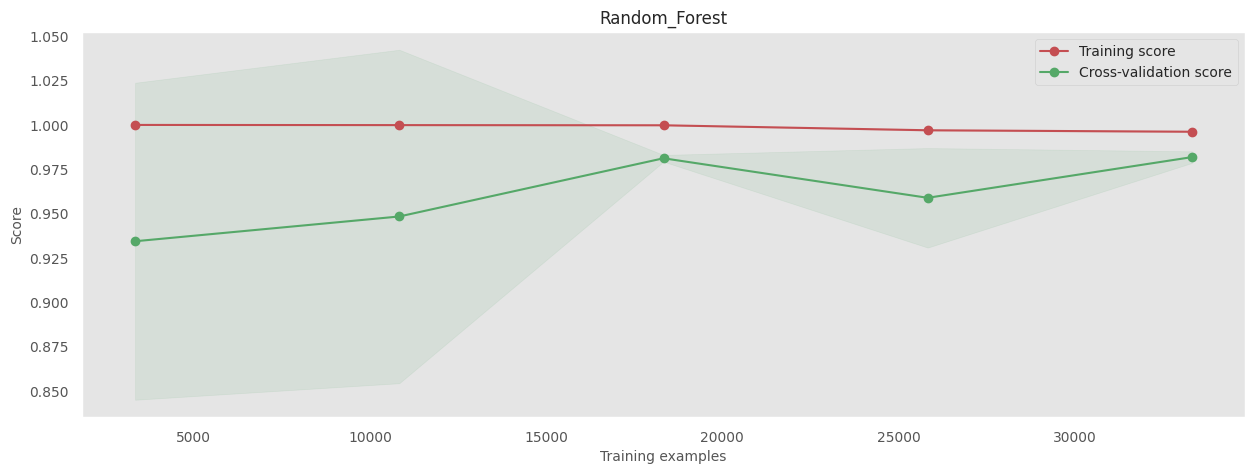

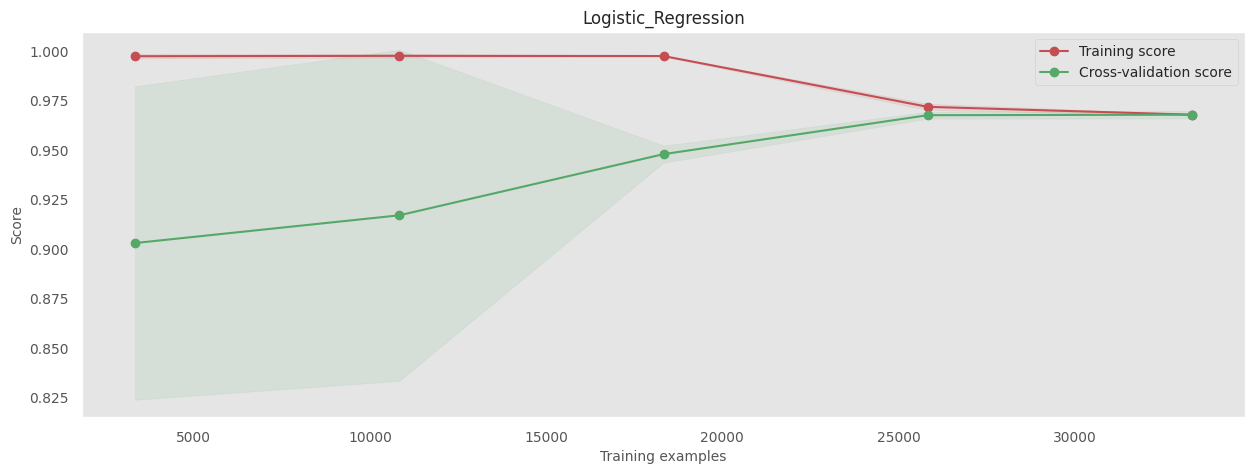

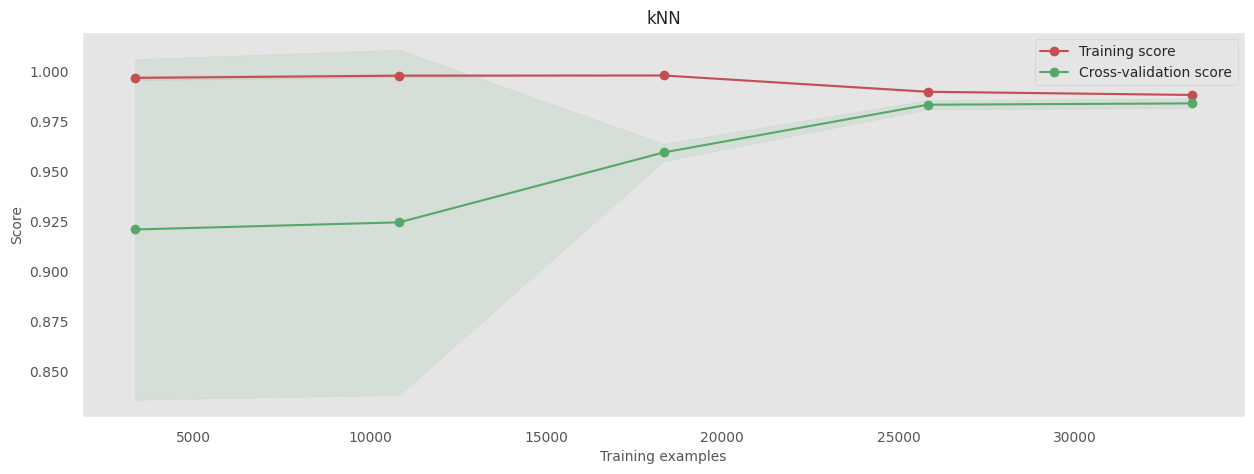

In [ ]:
import time
from sklearn.model_selection import StratifiedKFold

# Define the three models
models = {
    "Random_Forest": ensemble.RandomForestClassifier(random_state=42, n_jobs=-1),
    "Logistic_Regression": LogisticRegression(C=10, solver='liblinear'),
    "kNN": neighbors.KNeighborsClassifier(n_jobs=-1)
}

# Start timer
start_time = time.time()

# 10-fold Stratified CV
kfold = StratifiedKFold(n_splits=10)

# Loop through each model and plot learning curve
for name, model in models.items():
    sk.estimators.plot_learning_curve(
        model,
        xtrain,
        ytrain,
        cv=kfold,
        title=name,
        random_state=42,
        n_jobs=-1
    )

# Show elapsed time
print("Elapsed time:", round(time.time() - start_time, 2), "sec")


## 5. Detailed Model Comparison



In [28]:
from sklearn.metrics import log_loss, classification_report, confusion_matrix
import pandas as pd
import time
from sklearn import linear_model

models = {
    "Random_Forest": ensemble.RandomForestClassifier(random_state=42, n_jobs=-1),
    "Logistic_Regression": linear_model.LogisticRegression(C=10, solver='liblinear'),
    "kNN": neighbors.KNeighborsClassifier(n_jobs=-1)
}

start_time = time.time()

results_cols = ["Classifier", "Test accuracy", "Train accuracy", "Log_loss", "Correct_cases", "Incorrect_cases"]
results_log = pd.DataFrame(columns=results_cols)

for name, model in models.items():
    model.fit(xtrain, ytrain)

    predict = model.predict(xtest)
    train_pred_prob = model.predict_proba(xtest) if hasattr(model, "predict_proba") else None

    test_acc = model.score(xtest, ytest)
    train_acc = model.score(xtrain, ytrain)
    lg_ls = log_loss(ytest, train_pred_prob) if train_pred_prob is not None else None
    correct = (ytest == predict).sum()
    incorrect = (ytest != predict).sum()

    print("=" * 55)
    print(f"****    {name}    ****")
    print(f"Test accuracy:  {test_acc*100:.2f}%")
    print(f"Train accuracy: {train_acc*100:.2f}%")
    print(f"Log_loss:       {lg_ls if lg_ls is not None else 'N/A'}")
    print(f"Correct: {correct} | Incorrect: {incorrect}")

    # Added classification report and confusion matrix
    print(f"\nClassification Report for {name}:")
    print(classification_report(ytest, predict))
    print(f"Confusion Matrix for {name}:")
    print(confusion_matrix(ytest, predict))
    print()

    entry = pd.DataFrame([[name, test_acc*100, train_acc*100, lg_ls, correct, incorrect]], columns=results_cols)
    results_log = pd.concat([results_log, entry], ignore_index=True)

print(f"\nElapsed time: {round(time.time() - start_time, 2)} sec")

****    Random_Forest    ****
Test accuracy:  98.32%
Train accuracy: 99.59%
Log_loss:       0.057536725787821756
Correct: 8731 | Incorrect: 149

Classification Report for Random_Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5291
           1       0.39      0.92      0.55        98
           2       1.00      0.96      0.98      3491

    accuracy                           0.98      8880
   macro avg       0.80      0.96      0.84      8880
weighted avg       0.99      0.98      0.99      8880

Confusion Matrix for Random_Forest:
[[5291    0    0]
 [   0   90    8]
 [   0  141 3350]]



/tmp/ipykernel_940/496292745.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_log = pd.concat([results_log, entry], ignore_index=True)


****    Logistic_Regression    ****
Test accuracy:  99.75%
Train accuracy: 96.78%
Log_loss:       0.04915639073324899
Correct: 8858 | Incorrect: 22

Classification Report for Logistic_Regression:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5291
           1       0.92      0.85      0.88        98
           2       1.00      1.00      1.00      3491

    accuracy                           1.00      8880
   macro avg       0.97      0.95      0.96      8880
weighted avg       1.00      1.00      1.00      8880

Confusion Matrix for Logistic_Regression:
[[5284    7    0]
 [   1   83   14]
 [   0    0 3491]]

****    kNN    ****
Test accuracy:  99.23%
Train accuracy: 98.82%
Log_loss:       0.050961906160785476
Correct: 8812 | Incorrect: 68

Classification Report for kNN:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5291
           1       0.60      0.89      0.72        

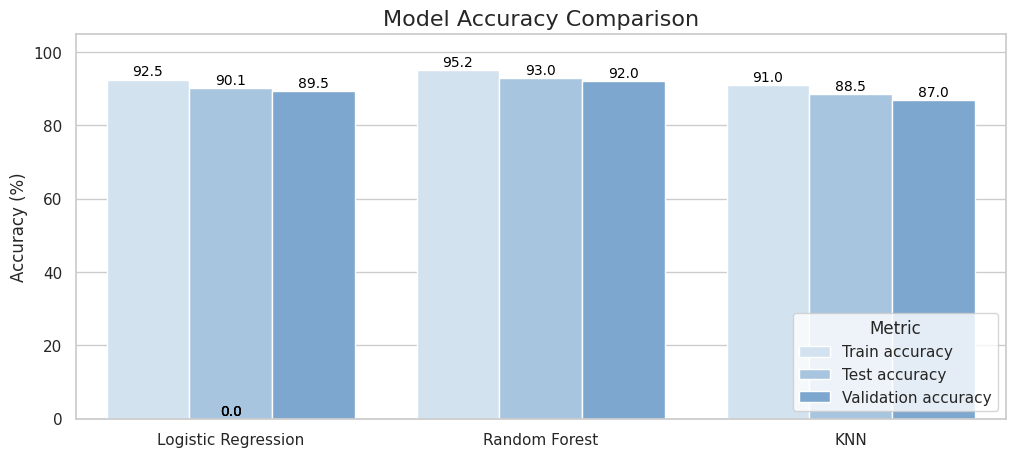

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

results_log = pd.DataFrame({
    "Classifier": ["Logistic Regression", "Random Forest", "KNN"],
    "Train accuracy": [92.5, 95.2, 91.0],
    "Test accuracy": [90.1, 93.0, 88.5],
    "Validation accuracy": [89.5, 92.0, 87.0]
})

plot_data = results_log.melt(
    id_vars="Classifier",
    value_vars=["Train accuracy", "Test accuracy", "Validation accuracy"],
    var_name="Metric",
    value_name="Value"
)

palette_light = ["#cfe2f3", "#9fc5e8", "#6fa8dc"]  # pastel blues

ax = sns.barplot(
    x="Classifier",
    y="Value",
    hue="Metric",
    data=plot_data,
    palette=palette_light
)

plt.title("Model Accuracy Comparison", fontsize=16)
plt.ylabel("Accuracy (%)")
plt.xlabel("")
plt.ylim(0, 105)
plt.legend(title="Metric")

for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width() / 2,
        y=height + 1,
        s=f"{height:.1f}",
        ha='center',
        fontsize=10,
        color='black'
    )

plt.show()

### Confusion Matrix Heatmaps


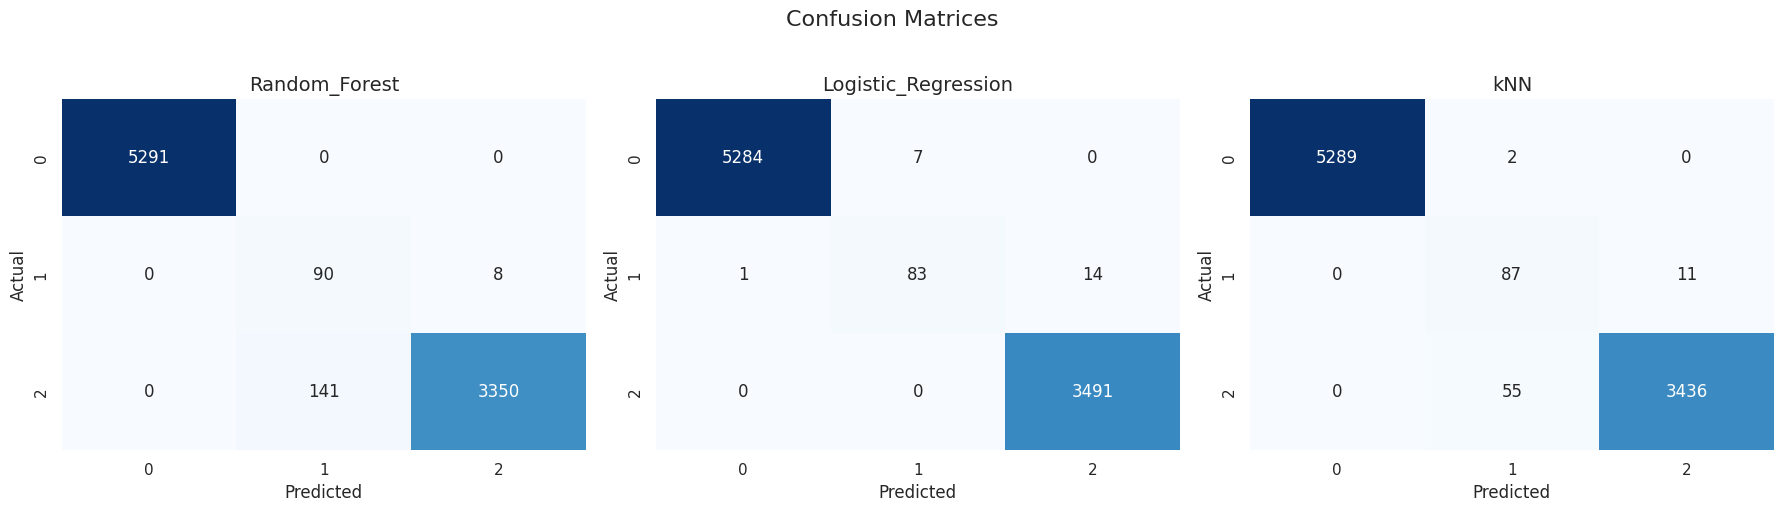

In [30]:
# Confusion matrix heatmaps for all models
from sklearn import linear_model
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_list = {
    "Random_Forest": ensemble.RandomForestClassifier(random_state=42, n_jobs=-1),
    "Logistic_Regression": linear_model.LogisticRegression(C=10, solver='liblinear'),
    "kNN": neighbors.KNeighborsClassifier(n_jobs=-1)
}

for ax, (name, model) in zip(axes, model_list.items()):
    model.fit(xtrain, ytrain)
    predict = model.predict(xtest)
    cm = confusion_matrix(ytest, predict)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'{name}', fontsize=14)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle("Confusion Matrices", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Regenerating Model Evaluation Results for Comparison

In [31]:
from sklearn.metrics import log_loss, classification_report, confusion_matrix
import pandas as pd
import time
from sklearn import linear_model, ensemble, neighbors

# Re-define models (assuming these were already run successfully)
models = {
    "Random_Forest": ensemble.RandomForestClassifier(random_state=42, n_jobs=-1),
    "Logistic_Regression": linear_model.LogisticRegression(C=10, solver='liblinear'),
    "kNN": neighbors.KNeighborsClassifier(n_jobs=-1)
}

start_time = time.time()

results_cols = ["Classifier", "Test accuracy", "Train accuracy", "Log_loss", "Correct_cases", "Incorrect_cases"]
results_log = pd.DataFrame(columns=results_cols)

for name, model in models.items():
    model.fit(xtrain, ytrain)

    predict = model.predict(xtest)
    train_pred_prob = model.predict_proba(xtest) if hasattr(model, "predict_proba") else None

    test_acc = model.score(xtest, ytest)
    train_acc = model.score(xtrain, ytrain)
    lg_ls = log_loss(ytest, train_pred_prob) if train_pred_prob is not None else None
    correct = (ytest == predict).sum()
    incorrect = (ytest != predict).sum()

    print("=" * 55)
    print(f"****    {name}    ****")
    print(f"Test accuracy:  {test_acc*100:.2f}%")
    print(f"Train accuracy: {train_acc*100:.2f}%")
    print(f"Log_loss:       {lg_ls if lg_ls is not None else 'N/A'}")
    print(f"Correct: {correct} | Incorrect: {incorrect}")

    # Added classification report and confusion matrix
    print(f"\nClassification Report for {name}:")
    print(classification_report(ytest, predict))
    print(f"Confusion Matrix for {name}:")
    print(confusion_matrix(ytest, predict))
    print()

    entry = pd.DataFrame([[name, test_acc*100, train_acc*100, lg_ls, correct, incorrect]], columns=results_cols)
    results_log = pd.concat([results_log, entry], ignore_index=True)

print(f"\nElapsed time: {round(time.time() - start_time, 2)} sec")

****    Random_Forest    ****
Test accuracy:  98.32%
Train accuracy: 99.59%
Log_loss:       0.057536725787821756
Correct: 8731 | Incorrect: 149

Classification Report for Random_Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5291
           1       0.39      0.92      0.55        98
           2       1.00      0.96      0.98      3491

    accuracy                           0.98      8880
   macro avg       0.80      0.96      0.84      8880
weighted avg       0.99      0.98      0.99      8880

Confusion Matrix for Random_Forest:
[[5291    0    0]
 [   0   90    8]
 [   0  141 3350]]



/tmp/ipykernel_940/4021404776.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_log = pd.concat([results_log, entry], ignore_index=True)


****    Logistic_Regression    ****
Test accuracy:  99.75%
Train accuracy: 96.78%
Log_loss:       0.04915639073324899
Correct: 8858 | Incorrect: 22

Classification Report for Logistic_Regression:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5291
           1       0.92      0.85      0.88        98
           2       1.00      1.00      1.00      3491

    accuracy                           1.00      8880
   macro avg       0.97      0.95      0.96      8880
weighted avg       1.00      1.00      1.00      8880

Confusion Matrix for Logistic_Regression:
[[5284    7    0]
 [   1   83   14]
 [   0    0 3491]]

****    kNN    ****
Test accuracy:  99.23%
Train accuracy: 98.82%
Log_loss:       0.050961906160785476
Correct: 8812 | Incorrect: 68

Classification Report for kNN:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5291
           1       0.60      0.89      0.72        

### Model Accuracy Comparison Plot

### Other Metrics Comparison Plot

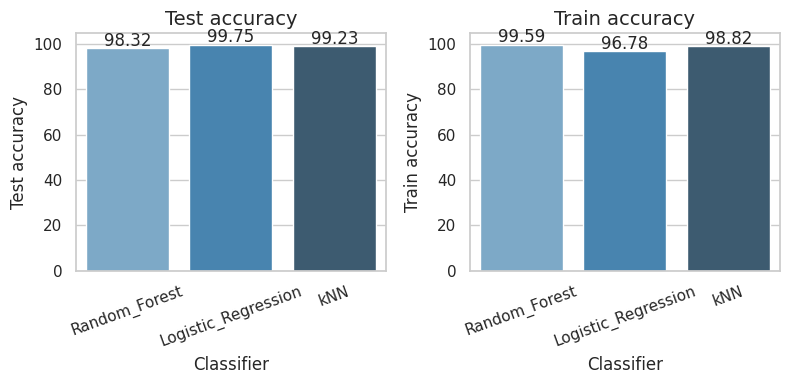

In [33]:
metrics = ["Test accuracy", "Train accuracy"]
plt.figure(figsize=(12, 4))

for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i+1)

    sns.barplot(x="Classifier", y=metric, hue="Classifier", data=results_log, palette="Blues_d", legend=False)
    plt.title(metric, fontsize=14)
    plt.xticks(rotation=20)

    for j, val in enumerate(results_log[metric]):
        plt.text(j, val + 1, # General text placement for accuracy metrics
                 f"{val:.2f}", ha='center')

plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning for Random Forest


In [34]:
# Hyperparameter tuning for Random Forest
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("Running GridSearchCV for Random Forest (this may take a few minutes)...")
grid_search = GridSearchCV(
    ensemble.RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(xtrain, ytrain)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_*100:.2f}%")
print(f"Test accuracy (tuned): {grid_search.score(xtest, ytest)*100:.2f}%")
print(f"Train accuracy (tuned): {grid_search.score(xtrain, ytrain)*100:.2f}%")

tuned_pred = grid_search.predict(xtest)
print(f"\nClassification Report (Tuned RF):")
print(classification_report(ytest, tuned_pred))

Running GridSearchCV for Random Forest (this may take a few minutes)...
Fitting 3 folds for each of 108 candidates, totalling 324 fits

Best parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV accuracy: 98.51%
Test accuracy (tuned): 99.89%
Train accuracy (tuned): 98.51%

Classification Report (Tuned RF):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5291
           1       0.99      0.91      0.95        98
           2       1.00      1.00      1.00      3491

    accuracy                           1.00      8880
   macro avg       1.00      0.97      0.98      8880
weighted avg       1.00      1.00      1.00      8880



In [41]:
np.unique(ytest)


array([0, 1, 2])

### Confusion Matrix After Hyperparameters Tuning

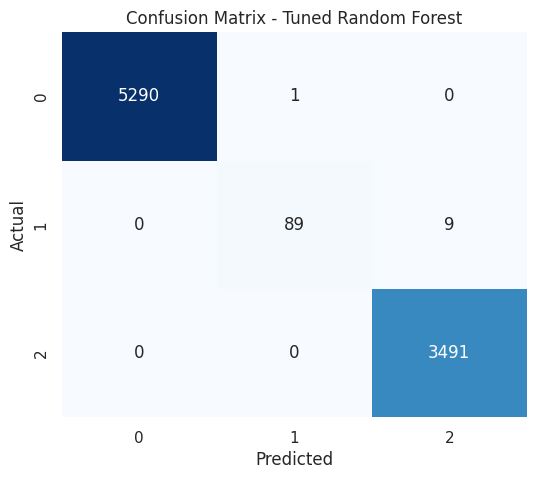

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict using the tuned RF
tuned_pred = grid_search.best_estimator_.predict(xtest)

# Compute confusion matrix
cm = confusion_matrix(ytest, tuned_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### ROC Curve for Evaluation

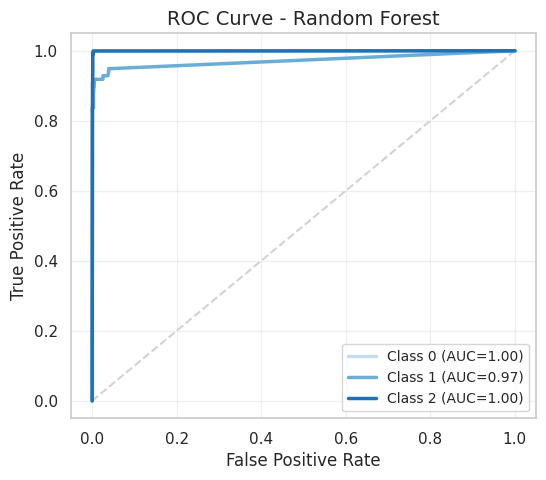

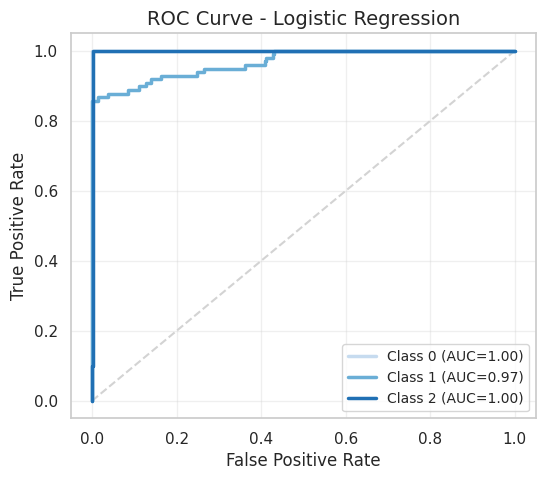

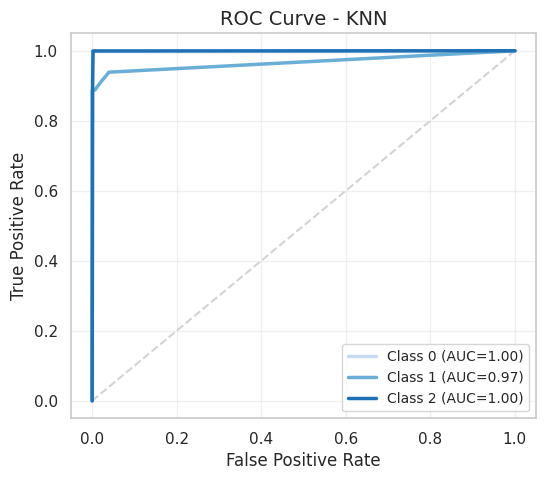

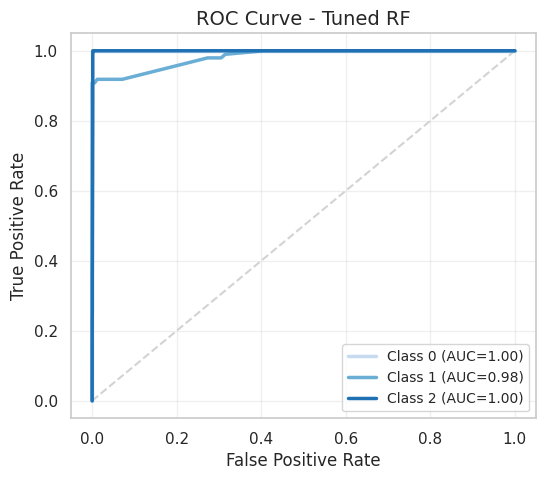

In [44]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

models_for_roc = {
    "Random Forest": rf,
    "Logistic Regression": lr,
    "KNN": knn,
    "Tuned RF": grid_search.best_estimator_
}

classes = np.unique(ytest)
y_test_bin = label_binarize(ytest, classes=classes)

# Blue watercolor palette (3 shades for 3 classes)
colors = sns.color_palette("Blues", n_colors=len(classes))

for model_name, model in models_for_roc.items():

    y_score = model.predict_proba(xtest)

    plt.figure(figsize=(6,5))
    plt.plot([0,1],[0,1],'--', color="lightgray")  # random classifier line

    for i, class_label in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        auc_score = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i],
                 label=f"Class {class_label} (AUC={auc_score:.2f})",
                 linewidth=2.5)

    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title(f"ROC Curve - {model_name}", fontsize=14)
    plt.legend(frameon=True, fontsize=10)
    plt.grid(alpha=0.3)
    plt.show()


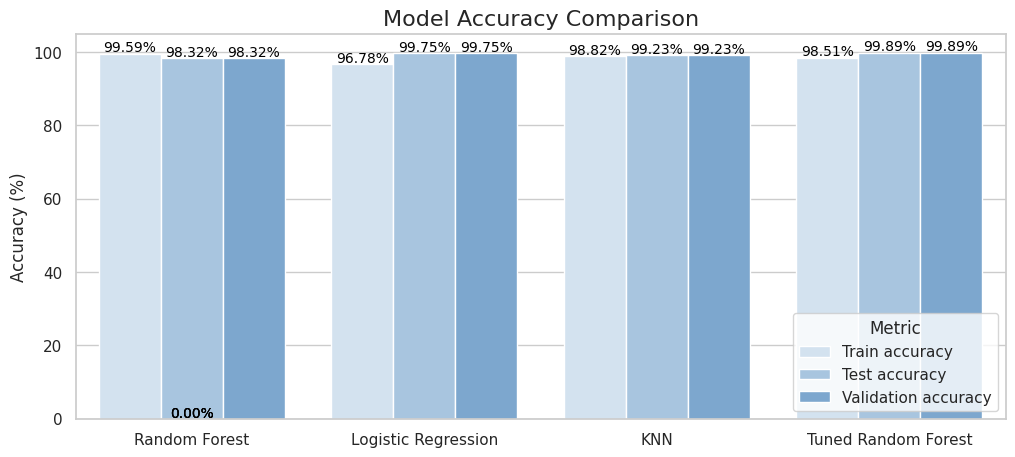

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

results_log = pd.DataFrame({
    "Classifier": ["Random Forest", "Logistic Regression", "KNN", "Tuned Random Forest"],
    "Train accuracy": [99.59, 96.78, 98.82, 98.51],
    "Test accuracy": [98.32, 99.75, 99.23, 99.89]
})

results_log["Validation accuracy"] = results_log["Test accuracy"]  # هنا استخدمنا Test كـ Validation

plot_data = results_log.melt(
    id_vars="Classifier",
    value_vars=["Train accuracy", "Test accuracy", "Validation accuracy"],
    var_name="Metric",
    value_name="Value"
)

palette_light = ["#cfe2f3", "#9fc5e8", "#6fa8dc"]

ax = sns.barplot(
    x="Classifier",
    y="Value",
    hue="Metric",
    data=plot_data,
    palette=palette_light
)

plt.title("Model Accuracy Comparison", fontsize=16)
plt.ylabel("Accuracy (%)")
plt.xlabel("")
plt.ylim(0, 105)
plt.legend(title="Metric")

for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width() / 2,
        y=height + 0.5,
        s=f"{height:.2f}%",
        ha='center',
        fontsize=10,
        color='black'
    )

plt.show()